In [52]:
import os
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models

In [53]:
import sys
import torch

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Python: d:\Sir. YKT_AIE\Myanmar-HandWritting-Dataset-Project\.venv\Scripts\python.exe
Torch: 2.11.0+cu128
CUDA available: True
Torch CUDA version: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060
Current device: 0
Using device: cuda


In [54]:
import sys
print(sys.executable)

d:\Sir. YKT_AIE\Myanmar-HandWritting-Dataset-Project\.venv\Scripts\python.exe


In [55]:
DATASET_ROOT = "single/Thiri_Shin_Thant"
MAX_CLASSES = 200
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
VAL_SAMPLES_PER_CLASS = 1
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
INPUT_CHANNELS = 1
EARLY_STOPPING_PATIENCE = 3
RESUME_FROM_CHECKPOINT = False
MODEL_TYPE = "cnn"

In [56]:
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [57]:
class MyanmarHandwritingDataset(Dataset):
    def __init__(self, root, transform=None, max_classes=None):
        self.root = Path(root)
        self.transform = transform

        self.image_paths = sorted([
            p for p in self.root.glob("*.png")
        ])

        if len(self.image_paths) == 0:
            raise ValueError(f"No PNG images found in {self.root}")

        samples = []
        bad_files = []

        for p in self.image_paths:
            try:
                # filename format: label-sample.png  ->  12-3.png
                label_text = p.stem.split("-")[0]

                # sanity check image can open
                with Image.open(p) as img:
                    img.verify()

                samples.append((p, label_text))
            except Exception as e:
                bad_files.append((p, str(e)))

        self.bad_files = bad_files

        all_labels = sorted(set(label for _, label in samples), key=lambda x: int(x))

        if max_classes is not None:
            selected = set(all_labels[:max_classes])
            samples = [(p, y) for (p, y) in samples if y in selected]
            all_labels = sorted(selected, key=lambda x: int(x))

        self.label2idx = {label: idx for idx, label in enumerate(all_labels)}
        self.idx2label = {idx: label for label, idx in self.label2idx.items()}

        self.samples = [(p, self.label2idx[label]) for p, label in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

Dataset checking

In [58]:
root = Path(DATASET_ROOT)
print("Dataset exists:", root.exists())
print("First 20 files:")

all_pngs = sorted(root.glob("*.png"))
for p in all_pngs[:20]:
    print(p.name)

Dataset exists: True
First 20 files:
1-1.png
1-2.png
1-3.png
10-1.png
10-2.png
10-3.png
100-1.png
100-2.png
100-3.png
1000-1.png
1000-2.png
1000-3.png
1001-1.png
1001-2.png
1001-3.png
1001-4.png
1002-1.png
1002-2.png
1002-3.png
1003-1.png


Check labels, class counts, image sizes

In [59]:
label_counter = Counter()
sizes = []
bad_files = []

for p in all_pngs:
    try:
        label = p.stem.split("-")[0]
        label_counter[label] += 1

        with Image.open(p) as img:
            sizes.append(img.size)
    except (UnidentifiedImageError, OSError, IOError) as e:
        bad_files.append((str(p), str(e)))

print("Total images found:", len(all_pngs))
print("Total classes found:", len(label_counter))
print("Bad/corrupted files:", len(bad_files))
print("Most common image sizes:", Counter(sizes).most_common(5))

counts = list(label_counter.values())
print("Min samples/class:", min(counts))
print("Max samples/class:", max(counts))
print("Mean samples/class:", np.mean(counts))
print("Median samples/class:", np.median(counts))

print("\nFirst 20 class counts:")
for i, (k, v) in enumerate(sorted(label_counter.items(), key=lambda x: int(x[0]))):
    if i >= 20:
        break
    print(k, v)

Total images found: 13343
Total classes found: 4413
Bad/corrupted files: 0
Most common image sizes: [((128, 128), 13343)]
Min samples/class: 3
Max samples/class: 5
Mean samples/class: 3.023566734647632
Median samples/class: 3.0

First 20 class counts:
1 3
2 3
3 3
4 3
5 3
6 3
7 3
8 3
9 3
10 3
11 3
12 3
13 3
14 3
15 3
16 3
17 3
18 3
19 3
20 4


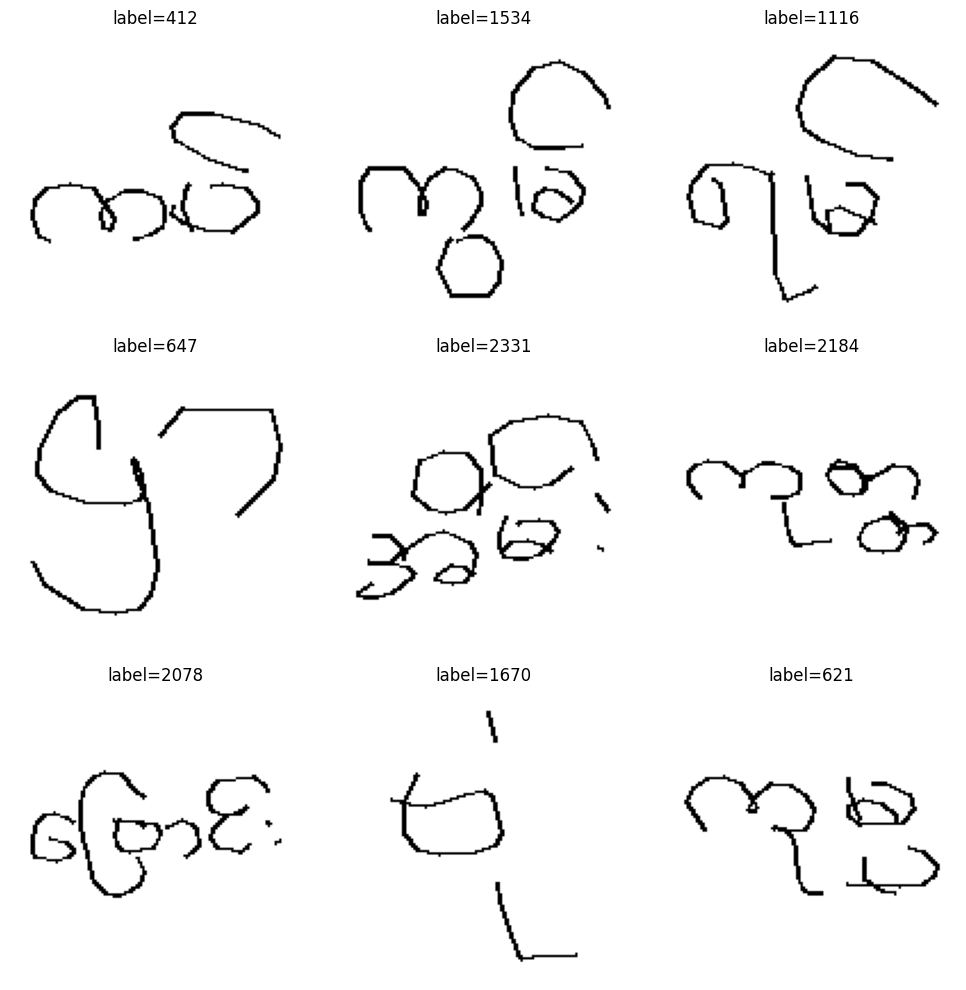

In [60]:
def show_random_images(root_dir, n=9):
    root_dir = Path(root_dir)
    files = sorted(root_dir.glob("*.png"))
    chosen = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(10, 10))
    for i, path in enumerate(chosen, 1):
        img = Image.open(path).convert("RGB")
        label = path.stem.split("-")[0]

        plt.subplot(int(np.ceil(n/3)), 3, i)
        plt.imshow(img)
        plt.title(f"label={label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(DATASET_ROOT, n=9)

Transforms

For all three folders, use RGB first.
That keeps stroke/time color information.

In [61]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=INPUT_CHANNELS),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * INPUT_CHANNELS, std=[0.5] * INPUT_CHANNELS),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=INPUT_CHANNELS),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * INPUT_CHANNELS, std=[0.5] * INPUT_CHANNELS),
])

Build dataset

In [62]:
full_dataset_for_info = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=val_transform,
    max_classes=MAX_CLASSES
)

print("Total samples:", len(full_dataset_for_info))
print("Total classes:", len(full_dataset_for_info.label2idx))
print("First 20 labels:", list(full_dataset_for_info.label2idx.keys())[:20])
print("Bad files inside dataset object:", len(full_dataset_for_info.bad_files))

Total samples: 612
Total classes: 200
First 20 labels: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
Bad files inside dataset object: 0


In [63]:
from collections import defaultdict
from torch.utils.data import Subset, DataLoader

def split_by_class(dataset, val_per_class=1, seed=42):
    rng = random.Random(seed)
    class_to_indices = defaultdict(list)

    for idx, (_, label) in enumerate(dataset.samples):
        class_to_indices[label].append(idx)

    train_indices = []
    val_indices = []

    for label, indices in class_to_indices.items():
        rng.shuffle(indices)

        if len(indices) <= val_per_class:
            train_indices.extend(indices[:-1])
            val_indices.extend(indices[-1:])
        else:
            val_indices.extend(indices[:val_per_class])
            train_indices.extend(indices[val_per_class:])

    return train_indices, val_indices


train_dataset = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=train_transform,
    max_classes=MAX_CLASSES
)

val_dataset = MyanmarHandwritingDataset(
    DATASET_ROOT,
    transform=val_transform,
    max_classes=MAX_CLASSES
)

train_indices, val_indices = split_by_class(train_dataset, val_per_class=VAL_SAMPLES_PER_CLASS, seed=SEED)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

if len(train_subset) == 0 or len(val_subset) == 0:
    raise ValueError("Empty train/val split. Check MAX_CLASSES and VAL_SAMPLES_PER_CLASS.")

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

num_classes = len(train_dataset.label2idx)

print("Train samples:", len(train_subset))
print("Val samples:", len(val_subset))
print("Num classes:", num_classes)
print("Workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Train samples: 412
Val samples: 200
Num classes: 200
Workers: 0
Pin memory: True


CNN

In [64]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, img_size=64, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        final_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * final_size * final_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Build model

In [65]:
model = SimpleCNN(num_classes=num_classes, img_size=IMG_SIZE, in_channels=INPUT_CHANNELS).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

start_epoch = 0
best_val_acc = 0.0
best_model_path = f"best_{Path(DATASET_ROOT).parts[0]}_{MODEL_TYPE}_{MAX_CLASSES}.pth"

if RESUME_FROM_CHECKPOINT and Path(best_model_path).exists():
    saved = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(saved["model_state_dict"])
    best_val_acc = saved.get("best_val_acc", 0.0)
    start_epoch = saved.get("epoch", 0)
    print(f"Resumed from {best_model_path} at epoch {start_epoch}")

print(model.__class__.__name__)

SimpleCNN


Train/eval functions

In [66]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def summarize_per_class_accuracy(preds, labels, idx2label, top_k=10):
    per_class_total = Counter(labels)
    per_class_correct = Counter()

    for pred, label in zip(preds, labels):
        if pred == label:
            per_class_correct[label] += 1

    rows = []
    for class_idx in sorted(per_class_total):
        total = per_class_total[class_idx]
        correct = per_class_correct[class_idx]
        acc = correct / total if total else 0.0
        rows.append({
            "class_idx": class_idx,
            "label": idx2label[class_idx],
            "correct": correct,
            "total": total,
            "acc": acc,
        })

    rows = sorted(rows, key=lambda x: (x["acc"], x["label"]))
    worst = rows[:top_k]
    best = sorted(rows, key=lambda x: (-x["acc"], x["label"]))[:top_k]
    return worst, best


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

In [67]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

checkpoint = None
epochs_without_improvement = 0
best_val_preds = []
best_val_labels = []

for epoch in range(start_epoch, EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        best_val_preds = val_preds
        best_val_labels = val_labels
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "label2idx": train_dataset.label2idx,
            "idx2label": train_dataset.idx2label,
            "config": {
                "dataset_root": DATASET_ROOT,
                "max_classes": MAX_CLASSES,
                "img_size": IMG_SIZE,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "lr": LR,
                "val_samples_per_class": VAL_SAMPLES_PER_CLASS,
                "model_type": MODEL_TYPE,
                "input_channels": INPUT_CHANNELS,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                "seed": SEED,
            },
            "epoch": epoch + 1,
            "best_val_acc": best_val_acc,
        }
        torch.save(checkpoint, best_model_path)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

print("Best validation accuracy:", best_val_acc)
print("Saved model to:", best_model_path)

if best_val_labels:
    worst_classes, best_classes = summarize_per_class_accuracy(
        best_val_preds,
        best_val_labels,
        train_dataset.idx2label,
        top_k=10,
    )

    print("\nWorst validation classes:")
    for row in worst_classes:
        print(f"label={row['label']} | acc={row['acc']:.2f} | {row['correct']}/{row['total']}")

    print("\nBest validation classes:")
    for row in best_classes:
        print(f"label={row['label']} | acc={row['acc']:.2f} | {row['correct']}/{row['total']}")

Epoch [1/10] | Train Loss: 5.3269 | Train Acc: 0.0024 | Val Loss: 5.2989 | Val Acc: 0.0050
Epoch [2/10] | Train Loss: 5.2997 | Train Acc: 0.0073 | Val Loss: 5.2989 | Val Acc: 0.0050
Epoch [3/10] | Train Loss: 5.2995 | Train Acc: 0.0049 | Val Loss: 5.2978 | Val Acc: 0.0050
Epoch [4/10] | Train Loss: 5.2995 | Train Acc: 0.0073 | Val Loss: 5.2948 | Val Acc: 0.0050
Early stopping triggered after 4 epochs.
Best validation accuracy: 0.005
Saved model to: best_single_cnn_200.pth

Worst validation classes:
label=1 | acc=0.00 | 0/1
label=10 | acc=0.00 | 0/1
label=100 | acc=0.00 | 0/1
label=101 | acc=0.00 | 0/1
label=102 | acc=0.00 | 0/1
label=103 | acc=0.00 | 0/1
label=104 | acc=0.00 | 0/1
label=105 | acc=0.00 | 0/1
label=106 | acc=0.00 | 0/1
label=107 | acc=0.00 | 0/1

Best validation classes:
label=97 | acc=1.00 | 1/1
label=1 | acc=0.00 | 0/1
label=10 | acc=0.00 | 0/1
label=100 | acc=0.00 | 0/1
label=101 | acc=0.00 | 0/1
label=102 | acc=0.00 | 0/1
label=103 | acc=0.00 | 0/1
label=104 | acc=0.

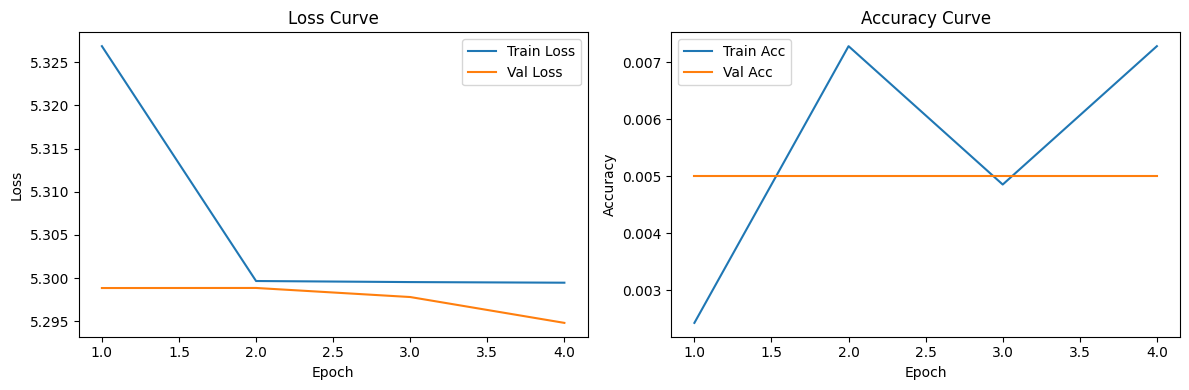

In [68]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()